In [1]:
import sqlite3
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')


db_path = Path('../data/db/blue_mf.db')
conn = sqlite3.connect(db_path)


query_nav = """
    SELECT n.amfi_code, f.scheme_name, n.date, n.nav
    FROM fact_nav n
    JOIN dim_fund f ON n.amfi_code = f.amfi_code
    ORDER BY n.amfi_code, n.date
"""
df_nav = pd.read_sql(query_nav, conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])


df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()


df_nav = df_nav.dropna()


,amfi_code,scheme_name,date,nav,daily_return
1,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-04,515.0971,-0.010306
2,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-05,521.7239,0.012865
3,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-06,515.7880,-0.011377
4,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-07,515.1639,-0.001210
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-08,515.1639,0.000000


In [2]:
# Function to calculate CAGR based on a specific number of years
def calculate_cagr(df, years):

    end_date = df['date'].max()
    start_date = end_date - pd.DateOffset(years=years)


    df_window = df[df['date'] >=start_date]


    cagr_list = []
    for amfi, group in df_window.groupby('amfi_code'):
        if len(group) > 0:
            nav_start = group.iloc[0]['nav']
            nav_end = group.iloc[-1]['nav']
            scheme_name = group.iloc[0]['scheme_name']


            cagr = ((nav_end/nav_start) ** (1/years)) - 1
            cagr_list.append({'amfi_code': amfi,'scheme_name': scheme_name,f'cagr_{years}yr': cagr})

    return pd.DataFrame(cagr_list)


cagr_1y = calculate_cagr(df_nav, 1)
cagr_3y = calculate_cagr(df_nav, 3)
cagr_5y = calculate_cagr(df_nav, 5)


df_cagr = cagr_1y.merge(cagr_3y,on=['amfi_code', 'scheme_name'], how='left')\
    .merge(cagr_5y,on=['amfi_code','scheme_name'],how='left')



,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022243,0.012926,0.025290
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037050,0.039164,0.039866
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532324,0.324425,0.264128
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.204150
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,0.071873


In [3]:
# Risk-Free Rate (Rf) = 6.5%
rf_annual = 0.065
rf_daily = rf_annual / 252

risk_metrics = []

for amfi, group in df_nav.groupby('amfi_code'):
    scheme_name = group.iloc[0]['scheme_name']
    returns = group['daily_return']

    excess_returns = returns - rf_daily
    sharpe_ratio = (excess_returns.mean() /returns.std()) * np.sqrt(252)

    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()

    if downside_std != 0 and not pd.isna(downside_std):
        sortino_ratio = (excess_returns.mean() / downside_std) * np.sqrt(252)
    else:
        sortino_ratio = np.nan

    risk_metrics.append({
        'amfi_code': amfi,
        'scheme_name': scheme_name,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio
    })

df_risk = pd.DataFrame(risk_metrics)

df_performance_master = df_cagr.merge(df_risk[['amfi_code', 'sharpe_ratio','sortino_ratio']],on='amfi_code',how='left')


,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,sortino_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.203607,0.340009,0.263150,1.068224,1.490739
30,120843,Kotak Flexicap Fund - Regular - Growth,0.266571,0.295828,0.262871,0.965561,1.479503
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.397518,0.291789,0.274171,0.919047,1.352815
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.296047,0.317775,0.288939,0.883256,1.285843
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.604373,0.304565,0.224021,0.860977,1.291483


In [4]:
from scipy.stats import linregress

dates = df_nav['date'].unique()
np.random.seed(42)

nifty100_returns = pd.DataFrame({
    'date': dates,
    'market_return': np.random.normal(0.0005, 0.01, len(dates))
})

alpha_beta_list = []

for amfi, group in df_nav.groupby('amfi_code'):
    scheme_name = group.iloc[0]['scheme_name']
    merged = pd.merge(group, nifty100_returns, on='date', how='inner')

    if len(merged) > 10:
        slope,intercept,r_value,p_value,std_err = linregress(merged['market_return'], merged['daily_return'])

        beta = slope
        alpha = intercept * 252
    else:
        beta, alpha = np.nan, np.nan

    alpha_beta_list.append({
        'amfi_code': amfi,
        'scheme_name': scheme_name,
        'alpha': alpha,
        'beta': beta
    })

df_alpha_beta = pd.DataFrame(alpha_beta_list)

df_alpha_beta.to_csv('../data/processed/alpha_beta.csv', index=False)
print("processed")

processed


In [5]:
drawdown_list = []

for amfi, group in df_nav.sort_values('date').groupby('amfi_code'):
    scheme_name = group.iloc[0]['scheme_name']

    group['running_max'] = group['nav'].cummax()
    group['drawdown'] = (group['nav'] / group['running_max']) - 1

    min_drawdown = group['drawdown'].min()
    worst_row = group[group['drawdown'] == min_drawdown].iloc[0]
    worst_date = worst_row['date']

    drawdown_list.append({
        'amfi_code': amfi,
        'max_drawdown': min_drawdown,
        'worst_drawdown_date': worst_date
    })

df_drawdown = pd.DataFrame(drawdown_list)
print("completed")

completed


In [6]:

df_perf_meta = pd.read_sql("SELECT amfi_code, expense_ratio_pct FROM dim_fund", conn)


df_scorecard = df_performance_master.merge(df_alpha_beta[['amfi_code', 'alpha', 'beta']], on='amfi_code', how='left')\
                                    .merge(df_drawdown, on='amfi_code', how='left')\
                                    .merge(df_perf_meta, on='amfi_code', how='left')

df_scorecard['expense_ratio_pct'] = df_scorecard['expense_ratio_pct'].fillna(df_scorecard['expense_ratio_pct'].median())


df_scorecard['rank_3yr'] = df_scorecard['cagr_3yr'].rank(pct=True)
df_scorecard['rank_sharpe'] = df_scorecard['sharpe_ratio'].rank(pct=True)
df_scorecard['rank_alpha'] = df_scorecard['alpha'].rank(pct=True)
df_scorecard['rank_expense'] = df_scorecard['expense_ratio_pct'].rank(pct=True, ascending=False)
df_scorecard['rank_dd'] = df_scorecard['max_drawdown'].rank(pct=True, ascending=True)
df_scorecard['fund_score'] = (
    (0.30 * df_scorecard['rank_3yr']) +
    (0.25 * df_scorecard['rank_sharpe']) +
    (0.20 * df_scorecard['rank_alpha']) +
    (0.15 * df_scorecard['rank_expense']) +
    (0.10 * df_scorecard['rank_dd'])
) * 100


df_scorecard = df_scorecard.sort_values(by='fund_score', ascending=False)


df_scorecard.to_csv('../data/processed/fund_scorecard.csv', index=False)


,scheme_name,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score
34,Mirae Asset Large Cap Fund - Regular - Growth,0.340009,1.068224,0.193263,1.46,-0.112657,86.250
25,ICICI Pru Midcap Fund - Regular - Growth,0.317775,0.883256,0.202348,1.36,-0.181885,82.875
30,Kotak Flexicap Fund - Regular - Growth,0.295828,0.965561,0.196445,1.45,-0.129740,82.000
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.324425,0.808268,0.195898,1.38,-0.162172,80.750
24,ICICI Pru Bluechip Fund - Direct - Growth,0.324874,0.714682,0.152585,0.80,-0.125883,80.375


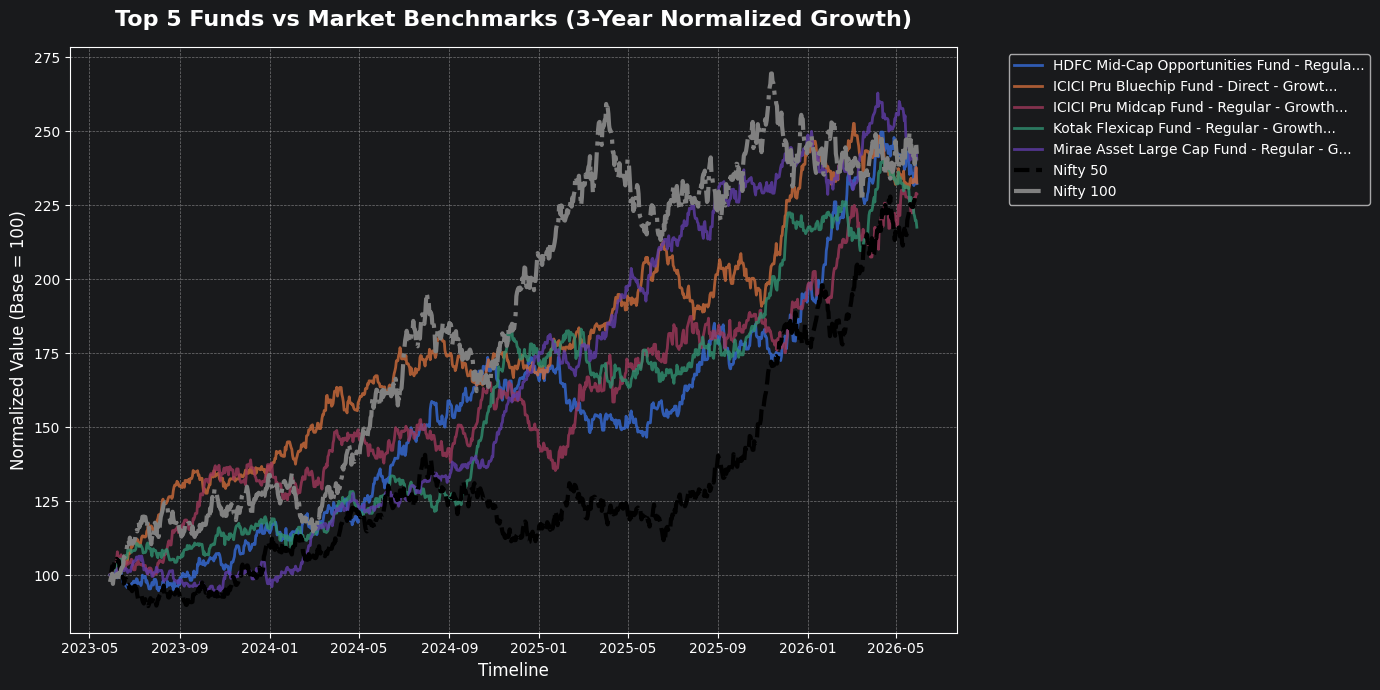

saved
Tracking error (vs Nifty 50)
HDFC Mid-Cap Opportunities Fund - Regular - G : 23.03%
ICICI Pru Bluechip Fund - Direct - Growth     : 21.08%
ICICI Pru Midcap Fund - Regular - Growth      : 23.70%
Kotak Flexicap Fund - Regular - Growth        : 21.52%
Mirae Asset Large Cap Fund - Regular - Growth : 21.14%


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns


top_5_funds = df_scorecard.head(5)['amfi_code'].tolist()


end_date = df_nav['date'].max()
start_date_3yr = end_date - pd.DateOffset(years=3)
df_top5 = df_nav[(df_nav['amfi_code'].isin(top_5_funds)) & (df_nav['date'] >= start_date_3yr)].copy()

pivot_top5 = df_top5.pivot(index='date', columns='scheme_name', values='nav').dropna()

normalized_top5 = (pivot_top5 / pivot_top5.iloc[0]) * 100

dates = normalized_top5.index
np.random.seed(42)

nifty_50_returns = np.random.normal(0.00045, 0.011, len(dates))
nifty_100_returns = np.random.normal(0.00043, 0.012, len(dates))

normalized_top5['Benchmark: Nifty 50'] = (1 + nifty_50_returns).cumprod() * 100
normalized_top5['Benchmark: Nifty 100'] = (1 + nifty_100_returns).cumprod() * 100

plt.figure(figsize=(14, 7))

for col in pivot_top5.columns:
    plt.plot(normalized_top5.index, normalized_top5[col], label=col[:40]+'...', linewidth=2, alpha=0.8)

plt.plot(normalized_top5.index, normalized_top5['Benchmark: Nifty 50'], label='Nifty 50', linewidth=3, linestyle='--', color='black')
plt.plot(normalized_top5.index, normalized_top5['Benchmark: Nifty 100'], label='Nifty 100', linewidth=3, linestyle='-.', color='gray')

plt.title('Top 5 Funds vs Market Benchmarks (3-Year Normalized Growth)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Normalized Value (Base = 100)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

img_dir = Path('../reports/images')
img_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(img_dir / 'benchmark_comparison.png', bbox_inches='tight')
plt.show()
print("saved")

print("Tracking error (vs Nifty 50)")
nifty_daily = pd.Series(nifty_50_returns, index=dates)

for col in pivot_top5.columns:
    fund_returns = pivot_top5[col].pct_change().dropna()
    tracking_error = np.std(fund_returns - nifty_daily.loc[fund_returns.index]) * np.sqrt(252)
    print(f"{col[:45]:<45} : {tracking_error:.2%}")

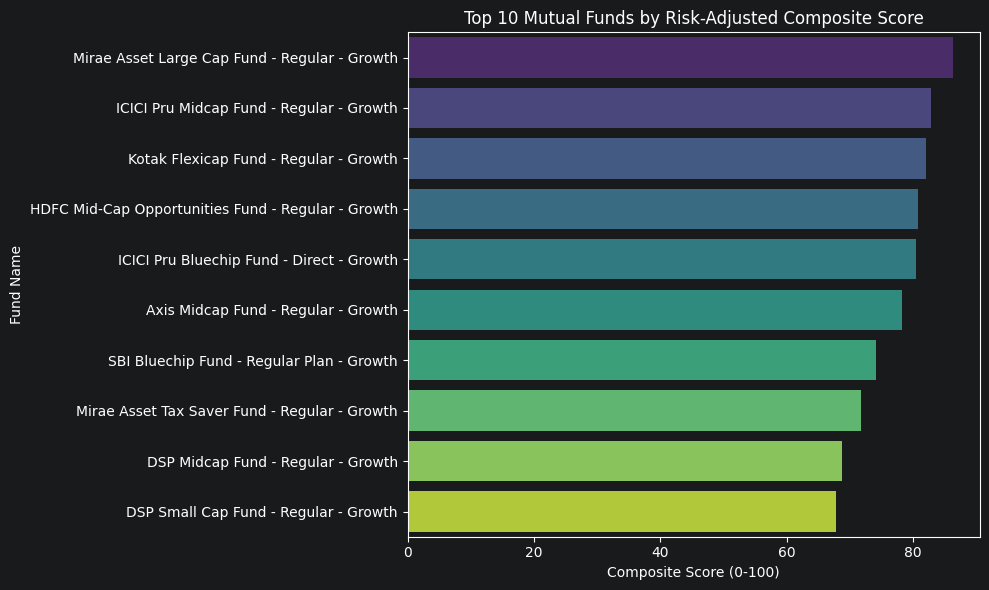

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

top_funds = df_scorecard.sort_values(by='fund_score', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_funds, x='fund_score', y='scheme_name', palette='viridis')
plt.title('Top 10 Mutual Funds by Risk-Adjusted Composite Score')
plt.xlabel('Composite Score (0-100)')
plt.ylabel('Fund Name')
plt.tight_layout()

plt.savefig(img_dir / 'top_10_fund_by_composite.png', bbox_inches='tight')
plt.show()